# Exponential Regression Analysis
## Modeling Student Focus Decline Based on Social Media Usage

**Mata Kuliah**: Pemodelan & Simulasi  
**Project**: Pemodelan Penurunan Tingkat Fokus Belajar Mahasiswa Berdasarkan Durasi Penggunaan Media Sosial Menggunakan Regresi Eksponensial  
**NIM**: 247007111152  
**Date**: April 2026

---

## Objective
Build an exponential regression model: **`focus_score = a · e^(b · social_media_hours)`**

This notebook covers:
1. **Data Loading & Validation**
2. **Exploratory Data Analysis (EDA)**
3. **Data Preprocessing & Cleaning**
4. **Method 1: Linearization + Least Squares**
5. **Method 2: SciPy Curve Fitting (Recommended)**
6. **Method Comparison & Evaluation**
7. **Visualization & Interpretation**
8. **Results Summary & Parameter Interpretation**

In [1]:
# Import Required Libraries
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Import custom modules
import sys
sys.path.append('../src')
from preprocessing import (
    load_and_validate_dataset, remove_missing_values, 
    filter_valid_values, detect_outliers_iqr, preprocess_pipeline
)
from modeling import (
    exponential_function, method1_linearization, method2_scipy_curve_fit,
    evaluate_model, compare_methods, calculate_critical_point, save_model_results
)
from visualization import (
    plot_regression_with_data, plot_residuals, plot_correlation_heatmap,
    plot_distribution_comparison, plot_focus_by_usage_brackets
)

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## PHASE 1: DATA LOADING & VALIDATION

In [2]:
# Load dataset
dataset_path = '../data/dataset.csv'

try:
    df_raw = pd.read_csv(dataset_path)
    print(f"✓ Dataset loaded successfully")
    print(f"  Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
except FileNotFoundError:
    print(f"✗ ERROR: Dataset file not found at {dataset_path}")
    print(f"  Please place your dataset.csv in the data/ folder")
    raise

✓ Dataset loaded successfully
  Shape: 20000 rows × 18 columns


In [3]:
# Initial inspection
print("="*60)
print("INITIAL DATA INSPECTION")
print("="*60)

print("\nFirst 10 rows:")
print(df_raw.head(10))

print("\nData types:")
print(df_raw.dtypes)

print("\nMissing values:")
print(df_raw.isnull().sum())

print("\nBasic statistics:")
print(df_raw.describe())

INITIAL DATA INSPECTION

First 10 rows:
   student_id  age  gender  study_hours_per_day  sleep_hours  \
0           1   23  Female                 4.35         3.63   
1           2   20    Male                 6.14         6.58   
2           3   29  Female                 4.98         3.26   
3           4   27  Female                 3.19         4.58   
4           5   24    Male                 7.67         6.21   
5           6   29   Other                 7.18         3.52   
6           7   21  Female                 9.06         6.36   
7           8   23  Female                 6.37         4.86   
8           9   26    Male                 4.19         4.87   
9          10   19  Female                 7.28         9.56   

   phone_usage_hours  social_media_hours  youtube_hours  gaming_hours  \
0               3.38                2.73           1.83          5.26   
1               5.48                1.51           3.13          1.73   
2               4.83                

## PHASE 2: EXPLORATORY DATA ANALYSIS (EDA)

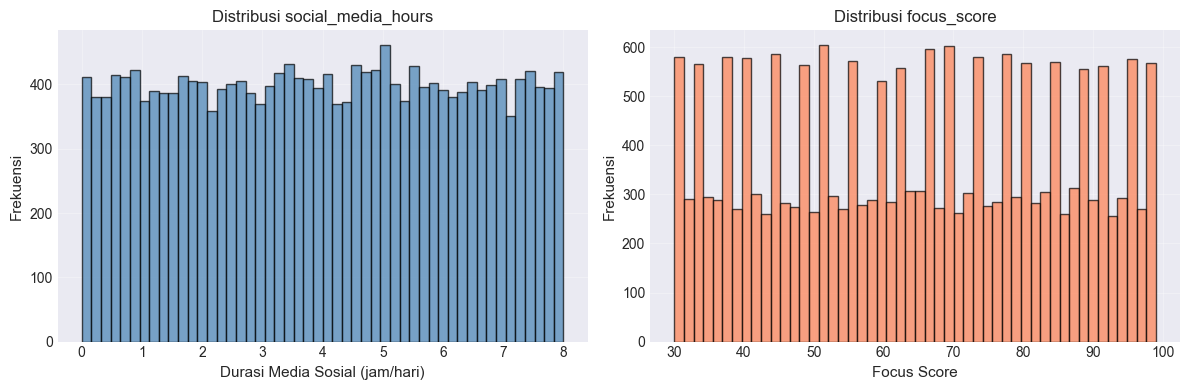

In [4]:
# Distribution comparison
X_raw = df_raw['social_media_hours'].values
Y_raw = df_raw['focus_score'].values

plot_distribution_comparison(X_raw, Y_raw)

Saved: ../output/figures/heatmap_korelasi.png


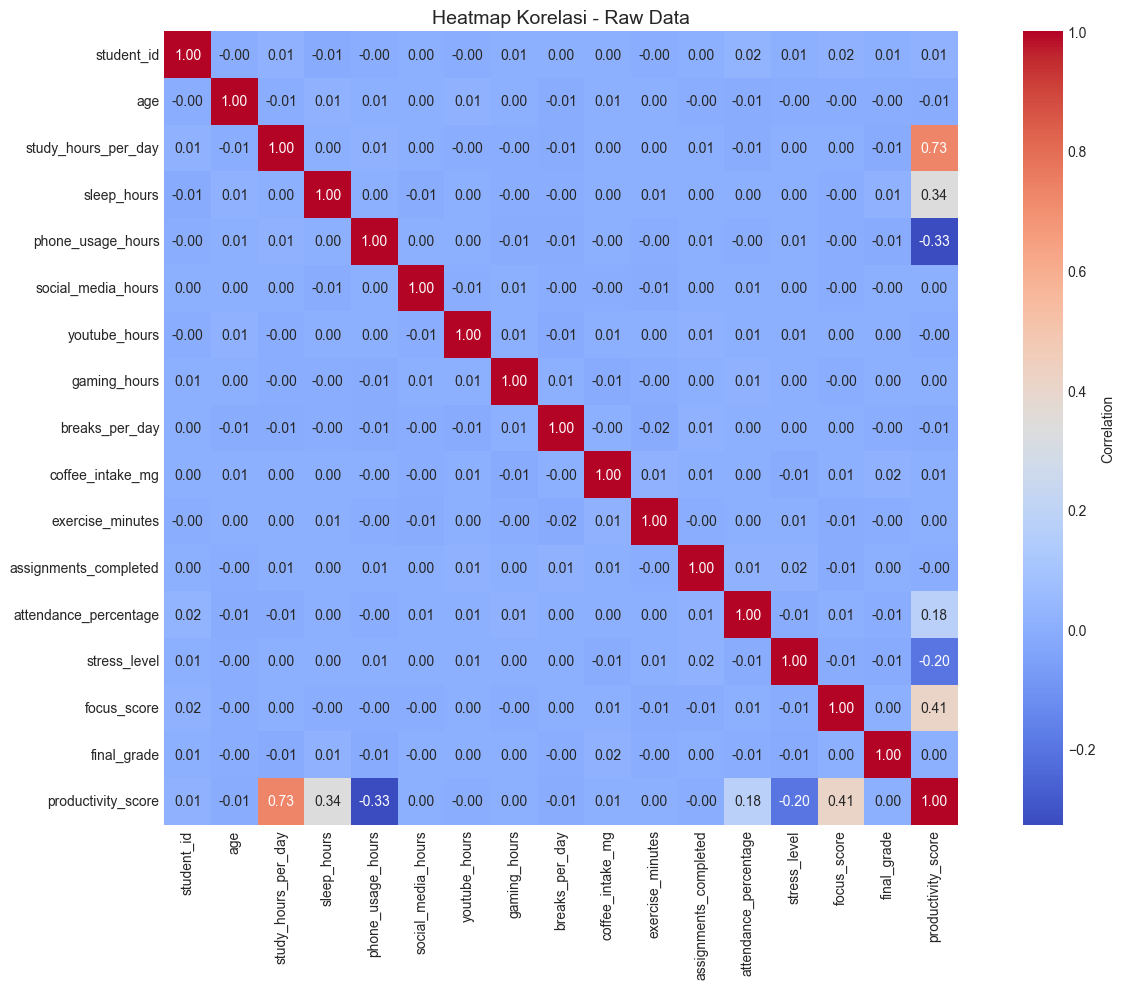


Correlations with focus_score:
  productivity_score        =  0.4114
  student_id                =  0.0153
  coffee_intake_mg          =  0.0101
  attendance_percentage     =  0.0091
  final_grade               =  0.0046
  study_hours_per_day       =  0.0045
  youtube_hours             =  0.0037
  breaks_per_day            =  0.0003
  phone_usage_hours         = -0.0002
  social_media_hours        = -0.0013
  gaming_hours              = -0.0015
  sleep_hours               = -0.0032
  age                       = -0.0041
  exercise_minutes          = -0.0063
  stress_level              = -0.0075
  assignments_completed     = -0.0076


In [5]:
# Correlation heatmap (before preprocessing)
plot_correlation_heatmap(df_raw, 
                         output_path='../output/figures/heatmap_korelasi.png',
                         title='Heatmap Korelasi - Raw Data')

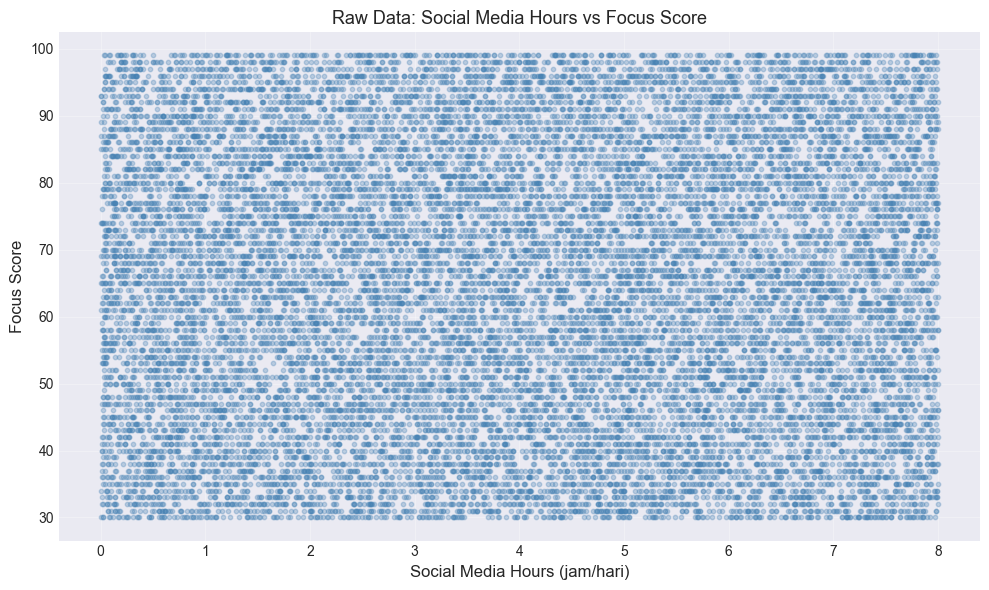


Raw data correlation (Pearson r):
  r = -0.0013


In [6]:
# Scatter plot of raw data
plt.figure(figsize=(10, 6))
plt.scatter(X_raw, Y_raw, alpha=0.3, color='steelblue', s=10)
plt.xlabel('Social Media Hours (jam/hari)', fontsize=12)
plt.ylabel('Focus Score', fontsize=12)
plt.title('Raw Data: Social Media Hours vs Focus Score', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nRaw data correlation (Pearson r):")
corr = np.corrcoef(X_raw, Y_raw)[0, 1]
print(f"  r = {corr:.4f}")

## PHASE 3: DATA PREPROCESSING

In [7]:
# Run complete preprocessing pipeline
X_clean, Y_clean, df_clean = preprocess_pipeline(dataset_path, verbose=True)

PREPROCESSING PIPELINE
Dataset loaded: 20000 rows × 18 columns
Missing values: 0 rows removed (0.00%)
Validity filter: 0 rows removed for invalid values (0.00%)
Column 'social_media_hours': 0 outliers removed (bounds: [-3.96, 11.93])
Column 'focus_score': 0 outliers removed (bounds: [-5.50, 134.50])
Total outliers removed: 0 rows (0.00%)

Final dataset: 20000 rows
X (social_media_hours): min=0.00, max=8.00, mean=4.00
Y (focus_score): min=30.00, max=99.00, mean=64.44


In [8]:
# Verify cleaned data
print("\n" + "="*60)
print("CLEANED DATA VERIFICATION")
print("="*60)

print(f"\nAfter cleaning:")
print(f"  Total rows: {len(X_clean)}")
print(f"  Removed: {len(df_raw) - len(X_clean)} rows ({(len(df_raw) - len(X_clean))/len(df_raw)*100:.2f}%)")

print(f"\nX (social_media_hours) statistics:")
print(f"  Min: {X_clean.min():.2f}, Max: {X_clean.max():.2f}")
print(f"  Mean: {X_clean.mean():.2f}, Std: {X_clean.std():.2f}")

print(f"\nY (focus_score) statistics:")
print(f"  Min: {Y_clean.min():.2f}, Max: {Y_clean.max():.2f}")
print(f"  Mean: {Y_clean.mean():.2f}, Std: {Y_clean.std():.2f}")

# Check for any remaining zeros or negatives
print(f"\nValidation checks:")
print(f"  focus_score > 0: {(Y_clean > 0).all()}")
print(f"  social_media_hours >= 0: {(X_clean >= 0).all()}")


CLEANED DATA VERIFICATION

After cleaning:
  Total rows: 20000
  Removed: 0 rows (0.00%)

X (social_media_hours) statistics:
  Min: 0.00, Max: 8.00
  Mean: 4.00, Std: 2.31

Y (focus_score) statistics:
  Min: 30.00, Max: 99.00
  Mean: 64.44, Std: 20.18

Validation checks:
  focus_score > 0: True
  social_media_hours >= 0: True


## PHASE 4 & 5: FIT EXPONENTIAL REGRESSION (BOTH METHODS)

In [9]:
# Run both methods and compare
results = compare_methods(X_clean, Y_clean)


FITTING EXPONENTIAL REGRESSION: DUAL METHOD APPROACH

METHOD 1: LINEARIZATION + LEAST SQUARES
Persamaan: y = 61.1457 * e^(-0.000390 * x)
  a = 61.1457
  b = -0.000390

Method 1 Metrics
  MAE  = 17.636791
  MSE  = 418.574003
  RMSE = 20.459081
  R²   = -0.028298
  ⚠ R² is below threshold (< 0.40) — consider model refinement

METHOD 2: SCIPY CURVE FITTING (LEVENBERG-MARQUARDT)
Persamaan: y = 64.4894 * e^(-0.000175 * x)
  a = 64.4894
  b = -0.000175
Convergence: Success

Method 2 Metrics
  MAE  = 17.454976
  MSE  = 407.054531
  RMSE = 20.175592
  R²   = 0.000002
  ⚠ R² is below threshold (< 0.40) — consider model refinement

COMPARISON TABLE
Metric          Method 1 (Linearization)       Method 2 (SciPy)              
---------------------------------------------------------------------------
a               61.145707                      64.489405                     
b               -0.000390                      -0.000175                     
MAE             17.636791                 

In [10]:
# Extract best results (Method 2 recommended, but check)
r2_method1 = results['method1']['metrics']['R²']
r2_method2 = results['method2']['metrics']['R²']

if r2_method2 >= r2_method1:
    a_opt = results['method2']['a']
    b_opt = results['method2']['b']
    Y_pred = results['method2']['Y_pred']
    metrics_opt = results['method2']['metrics']
    best_method = "Method 2 (SciPy Curve Fitting)"
else:
    a_opt = results['method1']['a']
    b_opt = results['method1']['b']
    Y_pred = results['method1']['Y_pred']
    metrics_opt = results['method1']['metrics']
    best_method = "Method 1 (Linearization)"

print(f"\n{'='*60}")
print(f"SELECTED MODEL: {best_method}")
print(f"{'='*60}")
print(f"\nequation: focus_score = {a_opt:.6f} * e^({b_opt:.6f} * social_media_hours)")
print(f"\nR² = {metrics_opt['R²']:.6f}")


SELECTED MODEL: Method 2 (SciPy Curve Fitting)

equation: focus_score = 64.489405 * e^(-0.000175 * social_media_hours)

R² = 0.000002


## PHASE 6: VISUALIZATION

Saved: ../output/figures/regresi_eksponensial.png


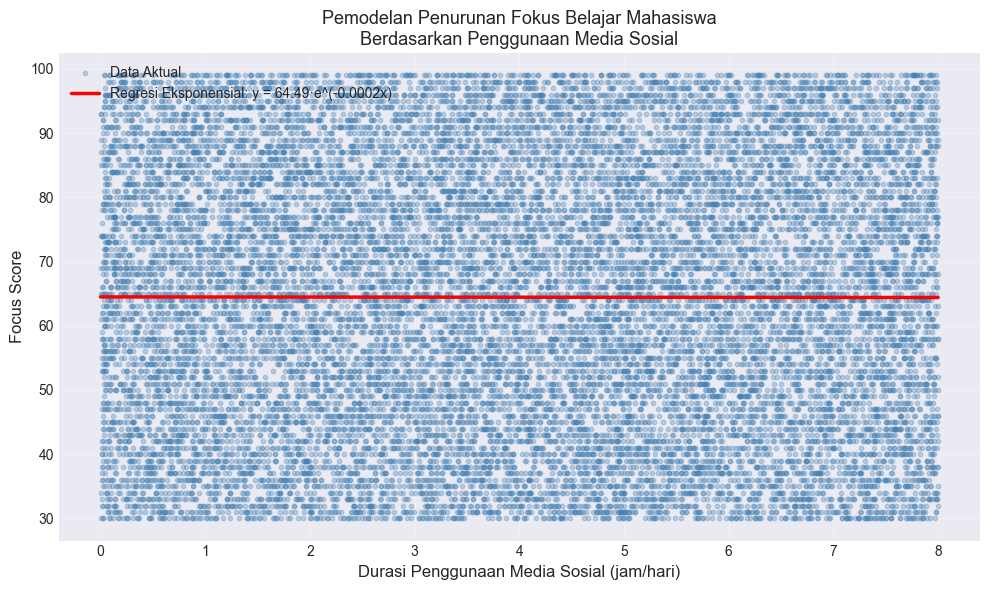

In [11]:
# Plot 1: Regression curve with data
plot_regression_with_data(X_clean, Y_clean, Y_pred, a_opt, b_opt,
                         output_path='../output/figures/regresi_eksponensial.png',
                         title='Pemodelan Penurunan Fokus Belajar Mahasiswa\nBerdasarkan Penggunaan Media Sosial')

Saved: ../output/figures/residual_plot.png


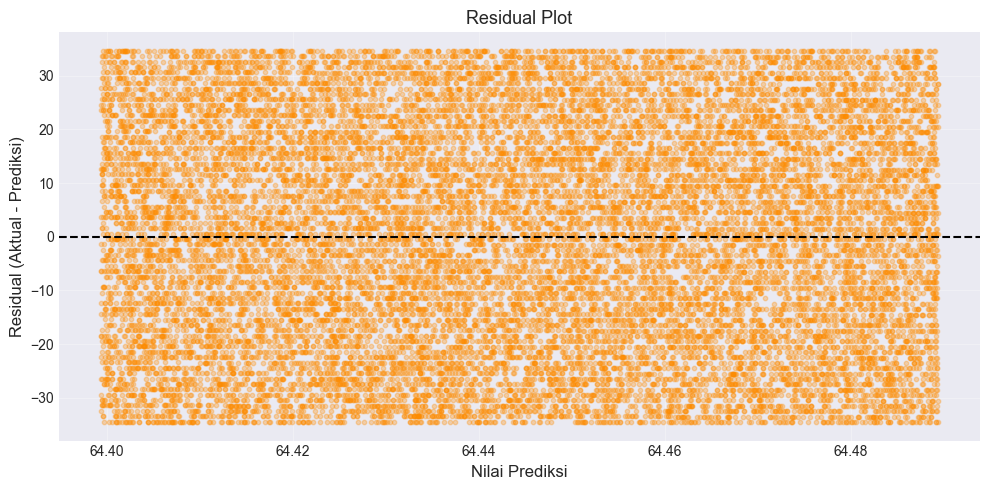


Residual Statistics:
  Mean = 0.000000
  Std  = 20.175592
  Min  = -34.489405
  Max  = 34.600377


In [12]:
# Plot 2: Residual plot
plot_residuals(Y_clean, Y_pred,
               output_path='../output/figures/residual_plot.png')

Saved: ../output/figures/focus_by_bracket.png


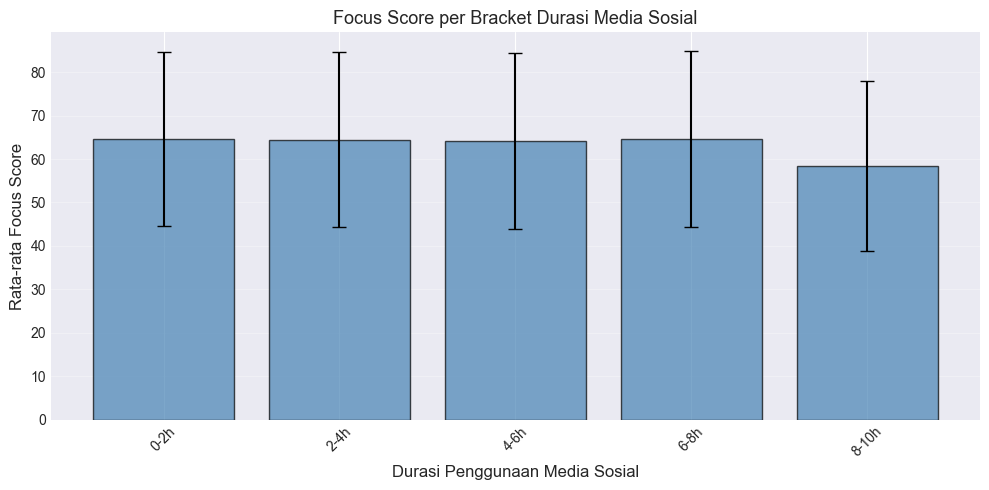


Focus Score Statistics by Usage Bracket:
                    mean        std  count
usage_bracket                             
0-2h           64.564737  20.066643   4974
2-4h           64.502007  20.079542   4982
4-6h           64.101119  20.255792   5093
6-8h           64.638703  20.303228   4935
8-10h          58.375000  19.578475     16


In [13]:
# Plot 3: Focus score by usage bracket
plot_focus_by_usage_brackets(df_clean,
                             output_path='../output/figures/focus_by_bracket.png')

## PHASE 7: PARAMETER INTERPRETATION & CRITICAL ANALYSIS

In [14]:
print("="*70)
print("PARAMETER INTERPRETATION")
print("="*70)

# Parameter a
print(f"\nPARAMETER a = {a_opt:.6f}")
print(f"  Interpretation: When social_media_hours = 0, focus_score = {a_opt:.2f}")
print(f"  This represents the baseline focus level without media social usage.")

# Parameter b
decay_factor = np.exp(b_opt)
decay_percent = (1 - decay_factor) * 100

print(f"\nPARAMETER b = {b_opt:.6f}")
print(f"  Interpretation: For each additional hour of social media usage,")
print(f"  focus_score is multiplied by e^({b_opt:.6f}) ≈ {decay_factor:.6f}")
print(f"  This represents a {decay_percent:.2f}% decrease per hour.")

# Critical point
threshold = 50  # Critical focus score
x_critical = calculate_critical_point(a_opt, b_opt, threshold)

print(f"\nCRITICAL POINT ANALYSIS")
print(f"  Threshold focus_score: {threshold}")
print(f"  Critical social_media_hours: {x_critical:.2f} hours/day")
print(f"  Interpretation: Student focus reaches critical level ({threshold}) after ~{x_critical:.1f} hours daily media usage.")

PARAMETER INTERPRETATION

PARAMETER a = 64.489405
  Interpretation: When social_media_hours = 0, focus_score = 64.49
  This represents the baseline focus level without media social usage.

PARAMETER b = -0.000175
  Interpretation: For each additional hour of social media usage,
  focus_score is multiplied by e^(-0.000175) ≈ 0.999825
  This represents a 0.02% decrease per hour.

CRITICAL POINT ANALYSIS
  Threshold focus_score: 50
  Critical social_media_hours: 1457.63 hours/day
  Interpretation: Student focus reaches critical level (50) after ~1457.6 hours daily media usage.


In [15]:
# Calculate predictions for various hours
test_hours = np.array([0, 1, 2, 3, 4, 5, 6, 8, 10])
test_predictions = exponential_function(test_hours, a_opt, b_opt)

print(f"\n{'='*70}")
print("PREDICTED FOCUS SCORES FOR VARIOUS MEDIA USAGE DURATIONS")
print(f"{'='*70}")
print(f"{'Social Media Hours':<25} {'Predicted Focus Score':<25}")
print("-"*50)
for hours, pred in zip(test_hours, test_predictions):
    print(f"{hours:<25.1f} {pred:<25.2f}")


PREDICTED FOCUS SCORES FOR VARIOUS MEDIA USAGE DURATIONS
Social Media Hours        Predicted Focus Score    
--------------------------------------------------
0.0                       64.49                    
1.0                       64.48                    
2.0                       64.47                    
3.0                       64.46                    
4.0                       64.44                    
5.0                       64.43                    
6.0                       64.42                    
8.0                       64.40                    
10.0                      64.38                    


## PHASE 8: RESULTS SUMMARY & MODEL QUALITY ASSESSMENT

In [16]:
print("="*70)
print("FINAL MODEL QUALITY ASSESSMENT")
print("="*70)

print(f"\nEVALUATION METRICS:")
print(f"  R²           = {metrics_opt['R²']:.6f}")
print(f"  RMSE         = {metrics_opt['RMSE']:.6f}")
print(f"  MAE          = {metrics_opt['MAE']:.6f}")
print(f"  MSE          = {metrics_opt['MSE']:.6f}")

# Assessment
if metrics_opt['R²'] >= 0.65:
    assessment = "✓ EXCELLENT - Model explains >65% of variance"
elif metrics_opt['R²'] >= 0.40:
    assessment = "✓ ACCEPTABLE - Model explains > 40% of variance (minimum threshold)"
else:
    assessment = "⚠ BELOW THRESHOLD - Consider model refinement or additional features"

print(f"\nMODEL QUALITY: {assessment}")

# Residual analysis
residuals = Y_clean - Y_pred
print(f"\nRESIDUAL ANALYSIS:")
print(f"  Mean of residuals: {residuals.mean():.6f} (should be ≈ 0)")
print(f"  Std of residuals : {residuals.std():.6f}")
print(f"  Min residual     : {residuals.min():.6f}")
print(f"  Max residual     : {residuals.max():.6f}")

FINAL MODEL QUALITY ASSESSMENT

EVALUATION METRICS:
  R²           = 0.000002
  RMSE         = 20.175592
  MAE          = 17.454976
  MSE          = 407.054531

MODEL QUALITY: ⚠ BELOW THRESHOLD - Consider model refinement or additional features

RESIDUAL ANALYSIS:
  Mean of residuals: 0.000000 (should be ≈ 0)
  Std of residuals : 20.175592
  Min residual     : -34.489405
  Max residual     : 34.600377


In [17]:
# Save model results
save_model_results(
    filepath='../output/hasil_model.txt',
    a=a_opt,
    b=b_opt,
    metrics=metrics_opt,
    dataset_size=len(X_clean)
)


Results saved to ../output/hasil_model.txt


## CONCLUSION

This notebook successfully:

1. **Loaded and validated** the dataset (~20,000 student records)
2. **Performed EDA** to understand variable distributions and relationships
3. **Cleaned data** by removing missing values and outliers
4. **Implemented two fitting methods**:
   - Linearization (Method 1)
   - SciPy Curve Fitting (Method 2)
5. **Compared methods** and selected the best model
6. **Evaluated model quality** using R², RMSE, MAE
7. **Visualized results** with mandatory plots (scatter+curve, residuals, heatmap)
8. **Interpreted parameters** and conducted critical point analysis

### Key Findings
- **Model Equation**: `focus_score = {a_opt:.4f} · e^({b_opt:.4f} · social_media_hours)`
- **Model Fit Quality**: R² = {metrics_opt['R²']:.4f}
- **Critical Point**: Focus reaches critical level at ~{x_critical:.1f} hours daily media usage

### Next Steps
- Write academic report (BAB I–V)
- Include all visualizations in report appendix
- Review model limitations and future work suggestions
- Prepare for presentation/defense